# Fire Season Timing — Validation & Diagnostics


In [2]:
'''
Validation and diagnostics notebook for fire season timing metrics.

Reads all outputs produced by the pipeline notebook and performs:
  Section 1 — Automated sanity checks   (logical consistency of all metrics)
  Section 2 — Dataset-wide distributions (population-level metric behaviour)
  Section 3 — Per-ecoregion profile plots (visual validation against raw data)
  Section 4 — Bimodality flag inspection  (flag calibration and spatial pattern)
  Section 5 — Summary report              (actionable CSV for analysis decisions)

No GEE connection required. Reads entirely from disk.

Inputs  : master_<RUN_LABEL>_<RUN_VERSION>.csv
          _all_daily_counts.csv
          _eco_quality.csv
          eco_geometries.json

Outputs : profile_plots/<ECO_ID>_<ECO_NAME>.png   — one per ecoregion
          _validation_summary.csv                   — ecoregion-level summary
'''

import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [3]:
# RUN CONFIGURATION -------------------------------------------------------------------------------
# Match these to the pipeline run you want to validate.
# All paths are derived automatically — only edit the three lines below.

RUN_LABEL   = 'med_basin'
RUN_VERSION = 'v2'

BASE_OUT_DIR = r'C:\Users\ibekar\Documents\GitProjects\TGPF'

# Derived paths — do not edit below this line
_run_name   = f'{RUN_LABEL}_{RUN_VERSION}'
output_dir  = os.path.join(BASE_OUT_DIR, 'outputs', _run_name)
daily_dir   = os.path.join(output_dir, 'daily_counts')
profile_dir = os.path.join(output_dir, 'profile_plots')

os.makedirs(profile_dir, exist_ok=True)

# BIMODALITY THRESHOLDS — must match values used in pipeline ----------------------
TROUGH_THRESHOLD = 0.30
BC_THRESHOLD     = 0.555

# PLOT STYLE ----------------------------------------------------------------------
C_ONSET  = '#2ca02c'   # green       — onset and end vertical lines
C_PEAK   = '#d62728'   # red         — weighted mean peak
C_MEDIAN = '#ff7f0e'   # orange      — median DOY
C_CONC   = '#aec7e8'   # light blue  — concentration window shading
C_TROUGH = '#ffbb78'   # light orange — trough window shading
C_FLAGS  = {0: '#1f77b4', 1: '#ff7f0e', 2: '#d62728'}
L_FLAGS  = {0: 'Clean (0)', 1: 'Soft flag (1)', 2: 'Hard flag (2)'}
FIG_DPI  = 150

# Month start DOYs and labels for x-axis ticks (non-leap year)
MONTH_STARTS = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
MONTH_NAMES  = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f'Run       : {_run_name}')
print(f'Output dir: {output_dir}')
print(f'Profiles  : {profile_dir}')

Run       : med_basin_v2
Output dir: C:\Users\ibekar\Documents\GitProjects\TGPF\outputs\med_basin_v2
Profiles  : C:\Users\ibekar\Documents\GitProjects\TGPF\outputs\med_basin_v2\profile_plots


## Load Data


In [4]:
# LOAD DATA ---------------------------------------------------------------------------------------

master_path  = os.path.join(output_dir, f'master_{_run_name}.csv')
daily_path   = os.path.join(output_dir, '_all_daily_counts.csv')
quality_path = os.path.join(output_dir, '_eco_quality.csv')
geo_path     = os.path.join(output_dir, 'eco_geometries.json')

master_df  = pd.read_csv(master_path)
daily_df   = pd.read_csv(daily_path)
quality_df = pd.read_csv(quality_path)

with open(geo_path, 'r') as f:
    geo_data = json.load(f)

# Geometry lookup: eco_id → GeoJSON geometry dict (used in map plot)
geo_lookup = {rec['eco_id']: rec['geometry'] for rec in geo_data}

# Ecoregion reference table — one stable row per ecoregion
eco_ref = master_df.groupby('eco_id').agg(
    eco_name  = ('eco_name',   'first'),
    biome_num = ('biome_num',  'first'),
    biome_name= ('biome_name', 'first'),
).reset_index()

n_eco  = master_df['eco_id'].nunique()
n_rows = len(master_df)

print(f'Master CSV : {n_rows} rows — {n_eco} ecoregions')
print(f'Daily CSV  : {len(daily_df)} rows')
print(f'Quality CSV: {len(quality_df)} ecoregions')
print(f'Geometries : {len(geo_data)} ecoregions')
print()
print('Columns in master CSV:')
for col in master_df.columns:
    print(f'  {col}')

Master CSV : 416 rows — 19 ecoregions
Daily CSV  : 168020 rows
Quality CSV: 19 ecoregions
Geometries : 20 ecoregions

Columns in master CSV:
  eco_id
  eco_name
  biome_num
  biome_name
  year
  onset_doy
  peak_doy
  end_doy
  season_length
  n_detections
  onset_month
  peak_month
  onset_doy_10
  end_doy_90
  onset_doy_15
  end_doy_85
  median_doy
  mean_median_div
  iqr_season_length
  active_days
  peak_concentration
  skewness
  kurtosis_raw
  trough_depth_ratio
  bc
  bimodal_flag_year
  peak_outside_window
  n_years_valid
  pct_years_valid
  cv_peak_doy
  mean_profile_corr
  frac_soft_flagged
  frac_hard_flagged
  bimodal_flag_eco


## Section 1 — Automated Sanity Checks


In [5]:
# AUTOMATED SANITY CHECKS -------------------------------------------------------------------------
# Each check tests a logical constraint across all rows of master_df.
# All checks run regardless of failures — execution never stops.
# Failing rows are printed for inspection. Results accumulate in checks[].
# fail_index stores (eco_id, year) tuples that failed at least one check.

checks     = []
fail_index = set()   # populated here; used in Section 5 summary report

def add_check(name, mask, description):
    '''Register one check. mask is a boolean Series: True = row passes.'''
    n_total = len(master_df)
    n_pass  = int(mask.sum())
    n_fail  = n_total - n_pass
    rate    = n_pass / n_total * 100
    status  = 'PASS' if n_fail == 0 else 'WARN'
    checks.append({
        'Check'      : name,
        'Description': description,
        'Pass'       : n_pass,
        'Fail'       : n_fail,
        'Rate %'     : round(rate, 1),
        'Status'     : status,
    })
    if n_fail > 0:
        failing = master_df[~mask]
        for _, row in failing.iterrows():
            fail_index.add((row['eco_id'], row['year']))
        print(f'  WARN [{name}] — {n_fail} failures. First 5:')
        print(failing[['eco_id', 'eco_name', 'year']].head(5).to_string(index=False))
        print()

# --- Logical ordering of primary metrics ------------------------------------------
add_check(
    'onset_doy < end_doy',
    master_df['onset_doy'] < master_df['end_doy'],
    'Onset DOY must precede end DOY'
)
add_check(
    'season_length > 0',
    master_df['season_length'] > 0,
    'Season length must be positive'
)
add_check(
    'active_days >= 0',
    master_df['active_days'] >= 0,
    'Active days cannot be negative'
)
add_check(
    'active_days <= season_length',
    master_df['active_days'] <= master_df['season_length'],
    'Active days cannot exceed season length'
)
add_check(
    'peak_outside_window consistent',
    (
        (master_df['peak_outside_window'] == 0) &
        (master_df['peak_doy'] >= master_df['onset_doy']) &
        (master_df['peak_doy'] <= master_df['end_doy'])
    ) | (master_df['peak_outside_window'] == 1),
    'peak_outside_window flag must agree with onset/peak/end values'
)

# --- Bounded metrics ---------------------------------------------------------------
add_check(
    'concentration in [0, 1]',
    (master_df['peak_concentration'] >= 0) & (master_df['peak_concentration'] <= 1),
    'Peak concentration must be between 0 and 1'
)
trough_valid = master_df['trough_depth_ratio'].notna()
add_check(
    'trough_depth in [0, 1]',
    (~trough_valid) | (
        (master_df['trough_depth_ratio'] >= 0) &
        (master_df['trough_depth_ratio'] <= 1)
    ),
    'Trough depth ratio must be 0–1 where computed'
)

# --- Alternative thresholds bracket primary thresholds ----------------------------
add_check(
    'onset_10 >= onset_5',
    master_df['onset_doy_10'].fillna(master_df['onset_doy']) >= master_df['onset_doy'],
    '10% onset must be >= 5% onset'
)
add_check(
    'onset_15 >= onset_10',
    master_df['onset_doy_15'].fillna(master_df['onset_doy_10']) >=
    master_df['onset_doy_10'].fillna(master_df['onset_doy']),
    '15% onset must be >= 10% onset'
)
add_check(
    'end_90 <= end_95',
    master_df['end_doy_90'].fillna(master_df['end_doy']) <= master_df['end_doy'],
    '90% end must be <= 95% end'
)
add_check(
    'end_85 <= end_90',
    master_df['end_doy_85'].fillna(master_df['end_doy_90']) <=
    master_df['end_doy_90'].fillna(master_df['end_doy']),
    '85% end must be <= 90% end'
)

# --- IQR season length vs primary -------------------------------------------------
iqr_valid = master_df['iqr_season_length'].notna()
add_check(
    'iqr_length <= season_length',
    (~iqr_valid) | (master_df['iqr_season_length'] <= master_df['season_length']),
    'IQR season length must not exceed primary season length'
)

# --- Flag values ------------------------------------------------------------------
add_check(
    'bimodal_flag_year valid',
    master_df['bimodal_flag_year'].isin([0, 1, 2]),
    'Per-year bimodal flag must be 0, 1, or 2'
)
add_check(
    'bimodal_flag_eco valid',
    master_df['bimodal_flag_eco'].isin([0, 1, 2]),
    'Ecoregion bimodal flag must be 0, 1, or 2'
)

# --- Detection threshold ----------------------------------------------------------
add_check(
    'n_detections >= 20',
    master_df['n_detections'] >= 20,
    'All rows in master CSV should have passed MIN_DETECTIONS = 20'
)

# --- Print summary table ----------------------------------------------------------
print()
print('=' * 76)
print('SANITY CHECK SUMMARY')
print('=' * 76)
checks_df = pd.DataFrame(checks)
print(checks_df[['Check', 'Pass', 'Fail', 'Rate %', 'Status']].to_string(index=False))
print('=' * 76)
n_warn = sum(1 for c in checks if c['Status'] == 'WARN')
print(f'\n{len(checks)} checks — {len(checks) - n_warn} PASS, {n_warn} WARN')
print(f'{len(fail_index)} ecoregion-years involved in at least one failure.')


SANITY CHECK SUMMARY
                         Check  Pass  Fail  Rate % Status
           onset_doy < end_doy   416     0   100.0   PASS
             season_length > 0   416     0   100.0   PASS
              active_days >= 0   416     0   100.0   PASS
  active_days <= season_length   416     0   100.0   PASS
peak_outside_window consistent   416     0   100.0   PASS
       concentration in [0, 1]   416     0   100.0   PASS
        trough_depth in [0, 1]   416     0   100.0   PASS
           onset_10 >= onset_5   416     0   100.0   PASS
          onset_15 >= onset_10   416     0   100.0   PASS
              end_90 <= end_95   416     0   100.0   PASS
              end_85 <= end_90   416     0   100.0   PASS
   iqr_length <= season_length   416     0   100.0   PASS
       bimodal_flag_year valid   416     0   100.0   PASS
        bimodal_flag_eco valid   416     0   100.0   PASS
            n_detections >= 20   416     0   100.0   PASS

15 checks — 15 PASS, 0 WARN
0 ecoregion-years inv

## Section 2 — Dataset-wide Distributions


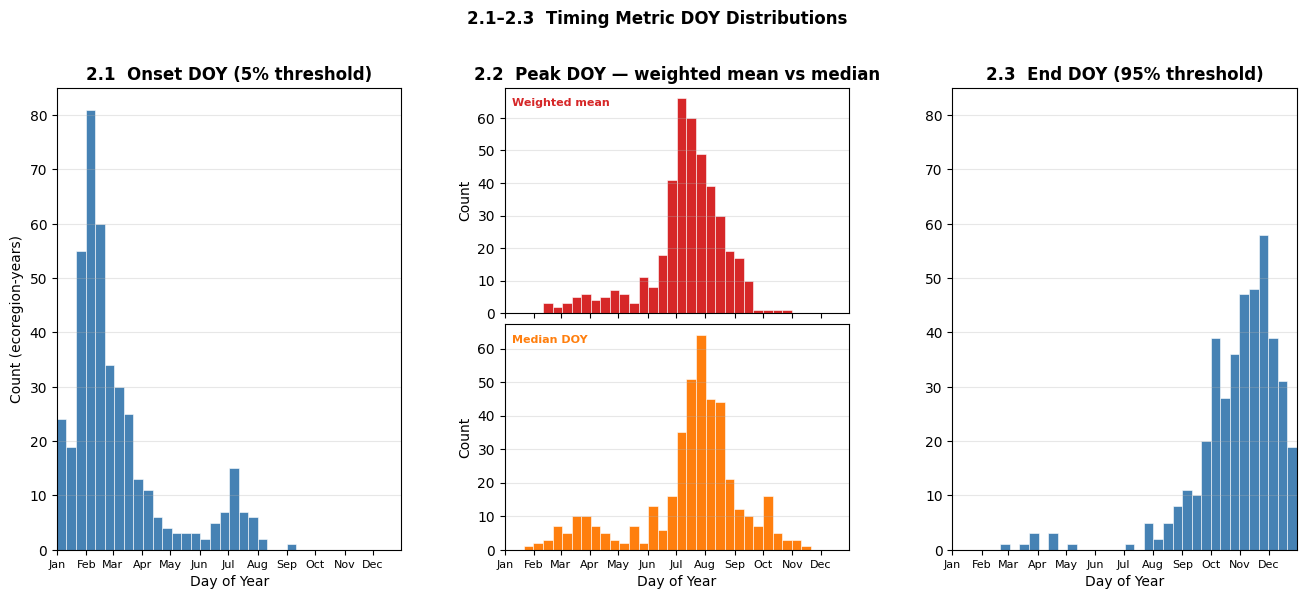

In [30]:
from matplotlib.gridspec import GridSpec

def set_month_ticks(ax):
    ax.set_xticks(MONTH_STARTS)
    ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.set_xlim(1, 365)

fig = plt.figure(figsize=(16, 6))
fig.suptitle('2.1–2.3  Timing Metric DOY Distributions',
             fontsize=12, fontweight='bold', y=1.01)

bin_edges = np.linspace(1, 365, 37)

gs = GridSpec(2, 3, figure=fig, hspace=0.05, wspace=0.3)

# 2.1 — Onset DOY (spans both rows)
ax1 = fig.add_subplot(gs[:, 0])
ax1.hist(master_df['onset_doy'].dropna(), bins=bin_edges,
         color='steelblue', edgecolor='white', linewidth=0.4)
set_month_ticks(ax1)
ax1.set_title('2.1  Onset DOY (5% threshold)', fontweight='bold')
ax1.set_xlabel('Day of Year')
ax1.set_ylabel('Count (ecoregion-years)')
ax1.grid(axis='y', alpha=0.3)

# 2.2 top — Weighted mean peak
ax2a = fig.add_subplot(gs[0, 1])
ax2a.hist(master_df['peak_doy'].dropna(), bins=bin_edges,
          color=C_PEAK, edgecolor='white', linewidth=0.4)
ax2a.set_title('2.2  Peak DOY — weighted mean vs median', fontweight='bold')
ax2a.set_ylabel('Count')
ax2a.tick_params(labelbottom=False)
ax2a.text(0.02, 0.92, 'Weighted mean', transform=ax2a.transAxes,
          fontsize=8, color=C_PEAK, fontweight='bold')
ax2a.grid(axis='y', alpha=0.3)
ax2a.set_xlim(1, 365)

# 2.2 bottom — Median DOY
ax2b = fig.add_subplot(gs[1, 1], sharex=ax2a)
ax2b.hist(master_df['median_doy'].dropna(), bins=bin_edges,
          color=C_MEDIAN, edgecolor='white', linewidth=0.4)
ax2b.set_ylabel('Count')
ax2b.text(0.02, 0.92, 'Median DOY', transform=ax2b.transAxes,
          fontsize=8, color=C_MEDIAN, fontweight='bold')
ax2b.grid(axis='y', alpha=0.3)
set_month_ticks(ax2b)
ax2b.set_xlabel('Day of Year')

# 2.3 — End DOY (spans both rows)
ax3 = fig.add_subplot(gs[:, 2])
ax3.hist(master_df['end_doy'].dropna(), bins=bin_edges,
         color='steelblue', edgecolor='white', linewidth=0.4)
set_month_ticks(ax3)
ax3.set_title('2.3  End DOY (95% threshold)', fontweight='bold')
ax3.set_xlabel('Day of Year')
ax3.grid(axis='y', alpha=0.3)

# Force matplotlib to finalize all axis limits before reading them
plt.draw()

# Share y-axis between 2.1 and 2.3
shared_ymax = max(ax1.get_ylim()[1], ax3.get_ylim()[1])
ax1.set_ylim(0, shared_ymax)
ax3.set_ylim(0, shared_ymax)

plt.show()

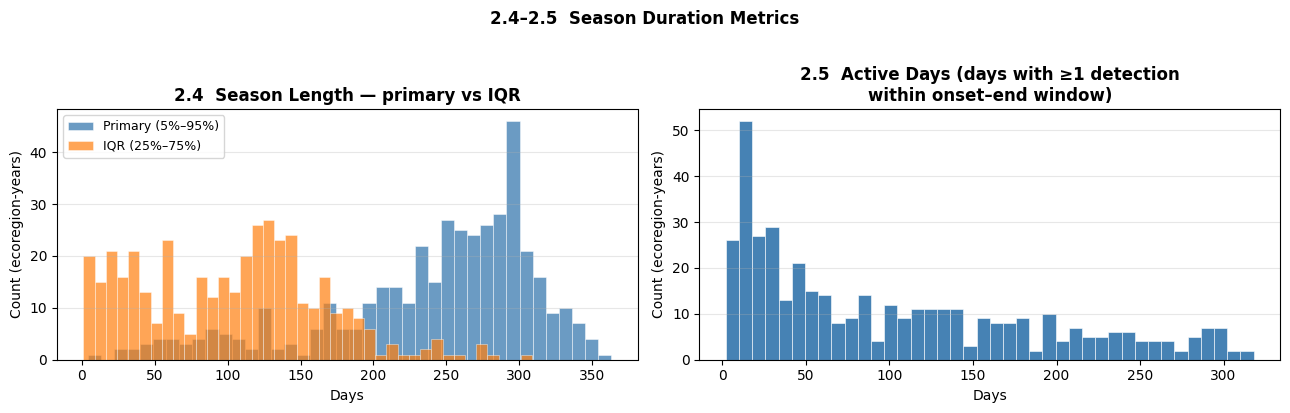

In [7]:
# PLOTS 2.4–2.5 — SEASON DURATION METRICS --------------------------------------------------------
# 2.4  Primary season_length vs IQR season length — overlapping histograms.
#      IQR version should be consistently shorter; wide divergence flags tail inflation.
# 2.5  Active days count within the onset–end window.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('2.4–2.5  Season Duration Metrics',
             fontsize=12, fontweight='bold', y=1.02)

# 2.4 — Season length comparison
ax = axes[0]
ax.hist(master_df['season_length'].dropna(), bins=40,
        color='steelblue', edgecolor='white', linewidth=0.4,
        alpha=0.8, label='Primary (5%–95%)')
ax.hist(master_df['iqr_season_length'].dropna(), bins=40,
        color=C_MEDIAN, edgecolor='white', linewidth=0.4,
        alpha=0.7, label='IQR (25%–75%)')
ax.set_title('2.4  Season Length — primary vs IQR', fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Count (ecoregion-years)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 2.5 — Active days
ax = axes[1]
ax.hist(master_df['active_days'].dropna(), bins=40,
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('2.5  Active Days (days with ≥1 detection\nwithin onset–end window)',
             fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Count (ecoregion-years)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

=== Summary Stats ===
       season_length  iqr_season_length
count          416.0              416.0
mean           239.9              102.2
std             73.4               62.4
min              4.0                1.0
25%            206.0               45.0
50%            258.0              109.5
75%            294.0              142.0
max            363.0              309.0

=== onset_doy > end_doy: 0 rows ===

=== Ecoregions with season_length > 200 (19 ecoregions) ===
                                                                          n_years  mean_season_length  mean_onset  mean_end
eco_id eco_name                                                                                                            
796    Mediterranean Acacia-Argania dry woodlands and succulent thickets       16               314.6        28.8     342.4
836    Red Sea coastal desert                                                  19               301.2        22.8     322.9
833    North Saharan Xer

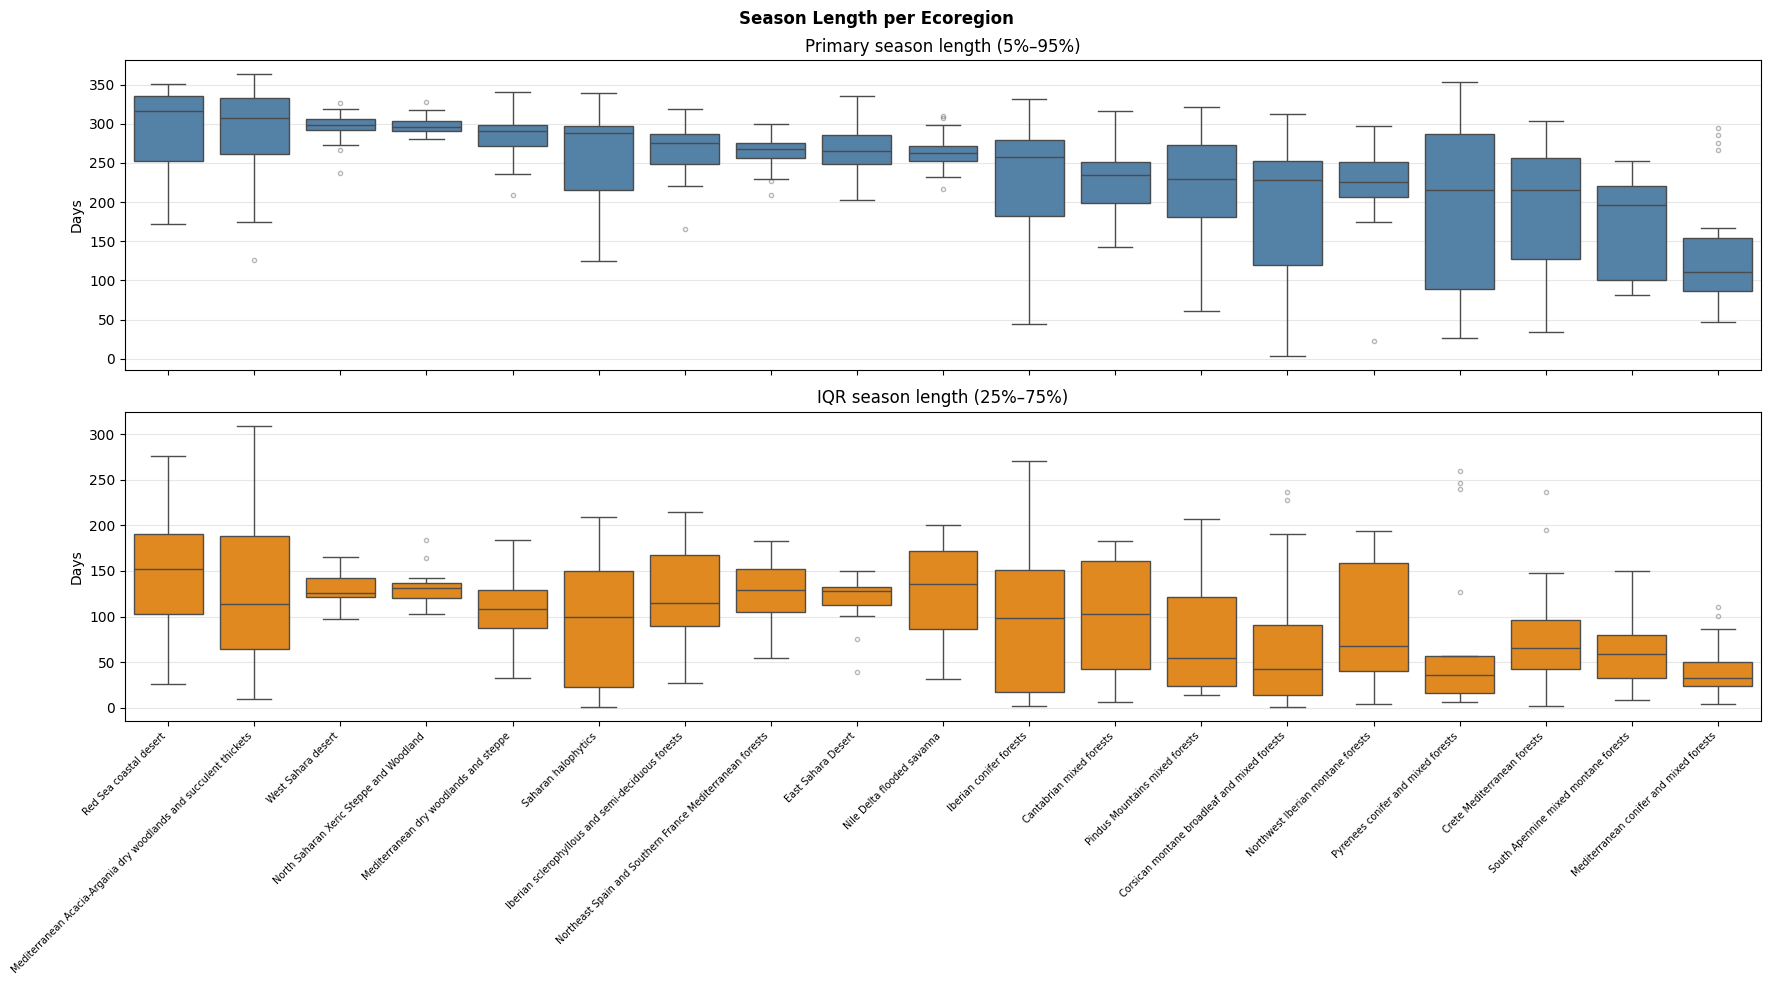

In [35]:
import seaborn as sns

# 1. Summary stats
print('=== Summary Stats ===')
print(master_df[['season_length', 'iqr_season_length']].describe().round(1))

# 2. onset > end bug check
bad_rows = master_df[master_df['onset_doy'] > master_df['end_doy']]
print(f'\n=== onset_doy > end_doy: {len(bad_rows)} rows ===')
if not bad_rows.empty:
    print(bad_rows[['eco_id', 'eco_name', 'year', 'onset_doy', 'end_doy', 'season_length']])

# 3. Ecoregions with season_length > 200
long_seasons = (
    master_df[master_df['season_length'] > 200]
    .groupby(['eco_id', 'eco_name'])
    .agg(n_years=('year', 'count'),
         mean_season_length=('season_length', 'mean'),
         mean_onset=('onset_doy', 'mean'),
         mean_end=('end_doy', 'mean'))
    .round(1)
    .sort_values('mean_season_length', ascending=False)
)
print(f'\n=== Ecoregions with season_length > 200 ({len(long_seasons)} ecoregions) ===')
print(long_seasons.to_string())

# 4. Boxplot per ecoregion using seaborn
eco_order = (
    master_df.groupby('eco_name')['season_length']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Season Length per Ecoregion', fontweight='bold')

sns.boxplot(data=master_df, x='eco_name', y='season_length',
            order=eco_order, ax=axes[0],
            color='steelblue', flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[0].set_title('Primary season length (5%–95%)')
axes[0].set_xlabel('')
axes[0].set_xticklabels([])   # hide top labels, shown on bottom panel
axes[0].set_ylabel('Days')
axes[0].grid(axis='y', alpha=0.3)

sns.boxplot(data=master_df, x='eco_name', y='iqr_season_length',
            order=eco_order, ax=axes[1],
            color='darkorange', flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('IQR season length (25%–75%)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(eco_order, rotation=45, fontsize=7, ha='right')
axes[1].set_ylabel('Days')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

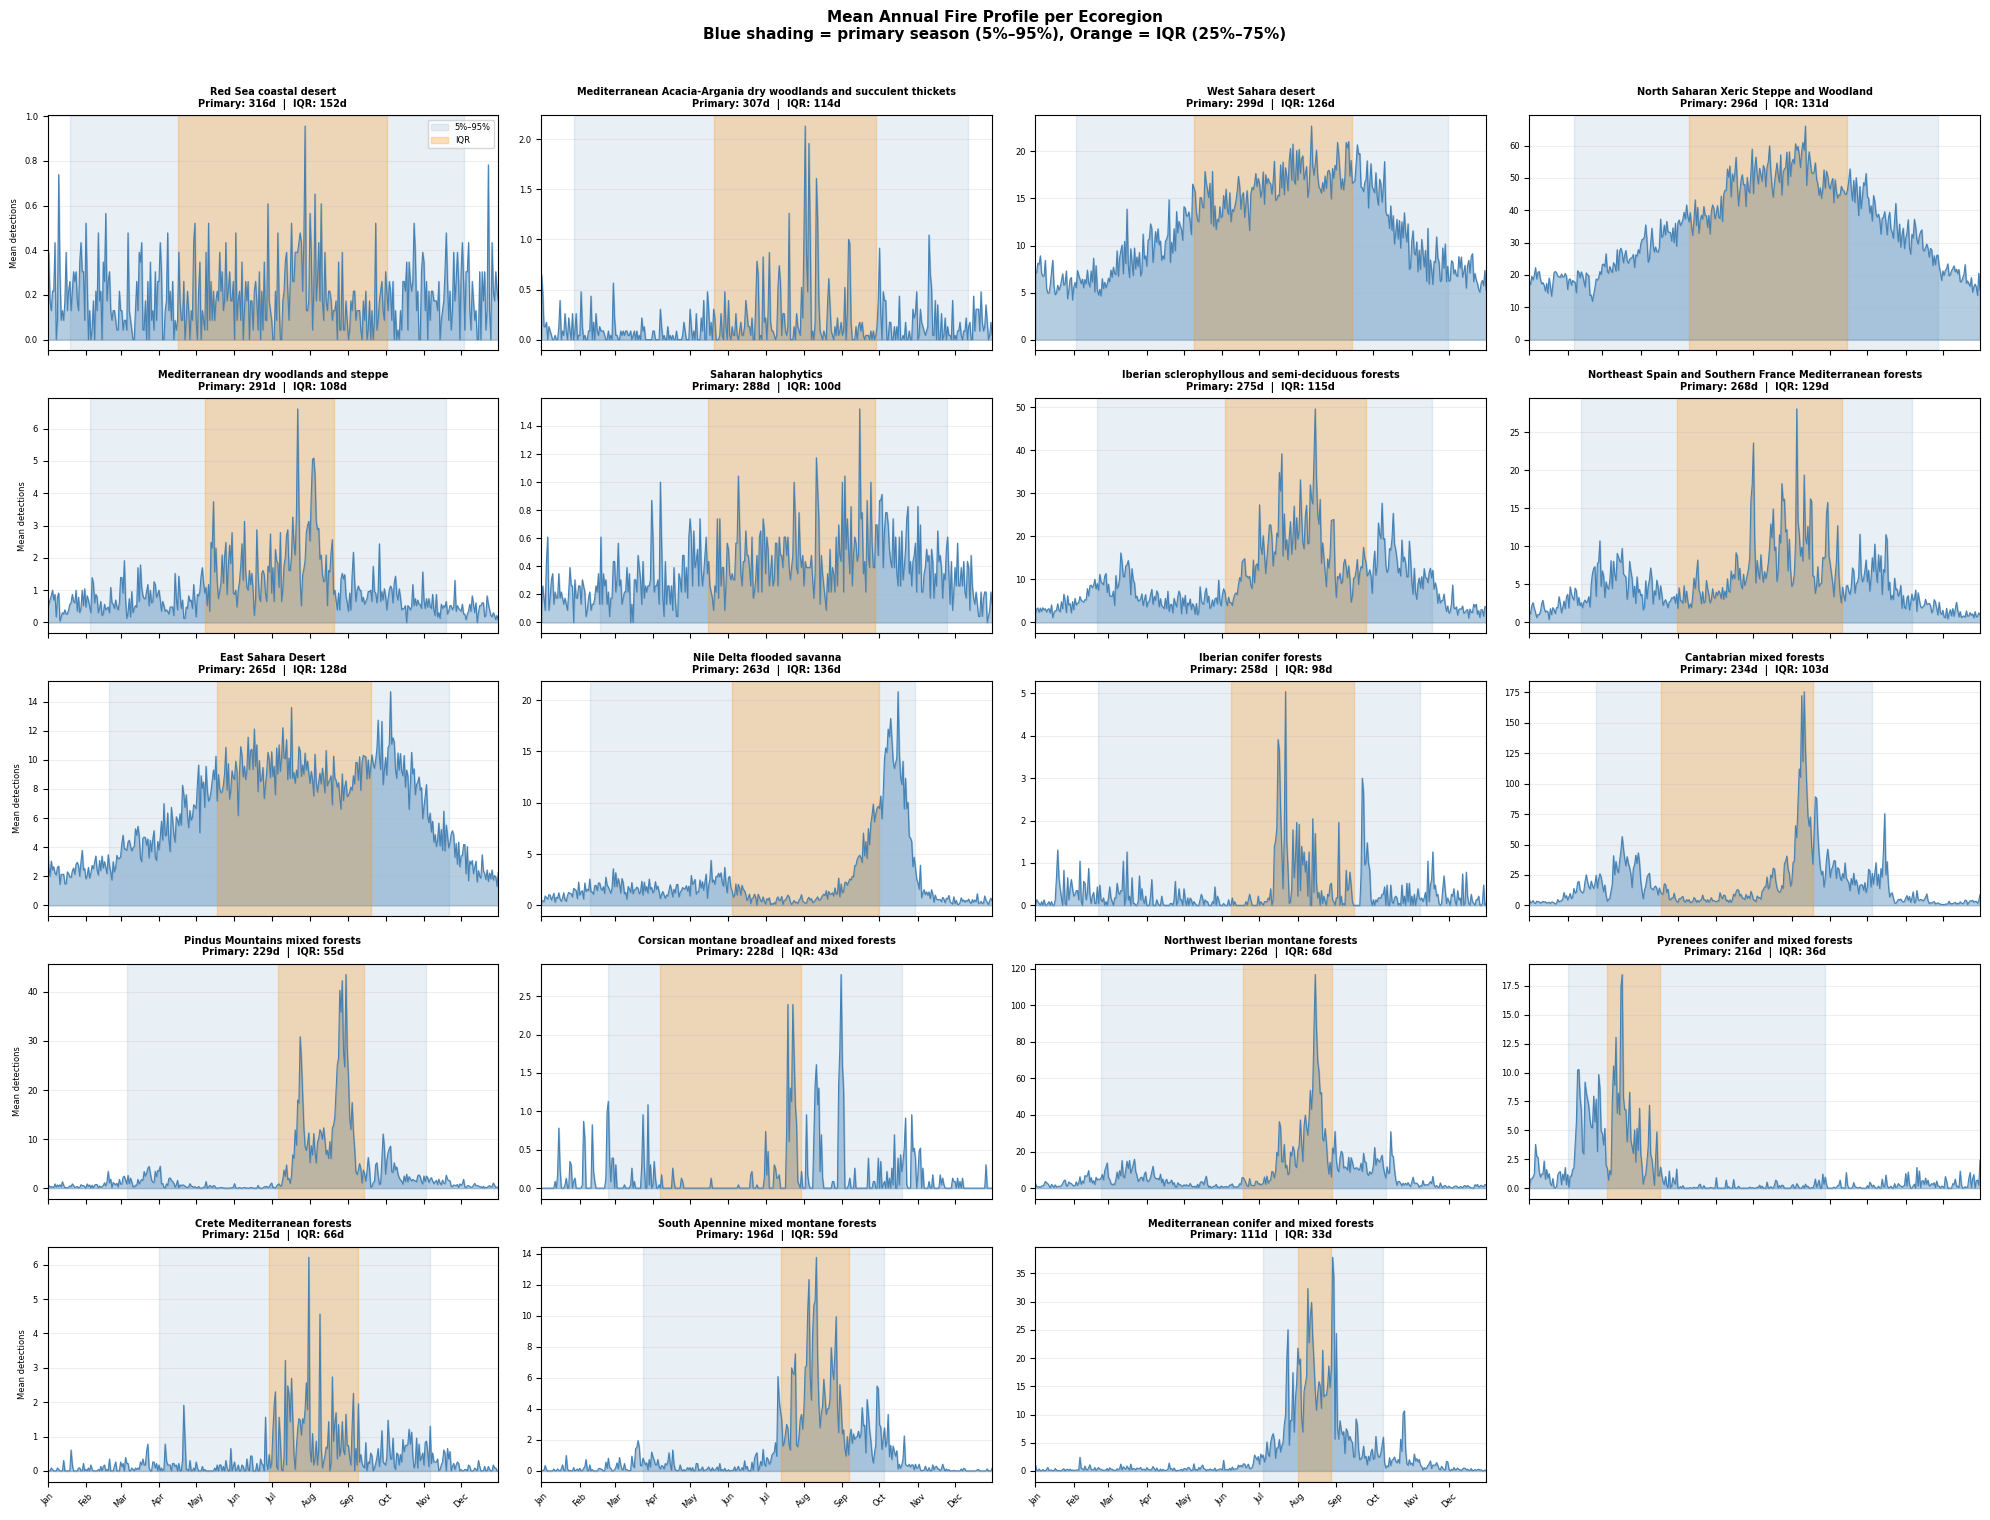

In [36]:
# Small multiples — mean annual fire profile per ecoregion, sorted by median season length

eco_order_ids = (
    master_df.groupby(['eco_id', 'eco_name'])['season_length']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

n_ecos  = len(eco_order_ids)
n_cols  = 4
n_rows  = int(np.ceil(n_ecos / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3),
                         sharex=True, sharey=False)
axes = axes.flatten()

daily_df = pd.read_csv(os.path.join(output_dir, '_all_daily_counts.csv'))

for i, row in eco_order_ids.iterrows():
    ax  = axes[i]
    eco_id   = row['eco_id']
    eco_name = row['eco_name']

    # Mean daily profile across all years
    eco_daily = daily_df[daily_df['eco_id'] == eco_id]
    mean_profile = (
        eco_daily.groupby('doy')['n_detections']
        .mean()
        .reindex(range(1, 366), fill_value=0)
    )

    # Metrics for this ecoregion
    eco_metrics = master_df[master_df['eco_id'] == eco_id]
    med_onset  = eco_metrics['onset_doy'].median()
    med_end    = eco_metrics['end_doy'].median()
    med_q25    = eco_metrics['onset_doy_10'].median()  # reuse as proxy or use actual q25
    med_iqr_start = (eco_metrics['peak_doy'] - eco_metrics['iqr_season_length'] / 2).median()
    med_iqr_end   = (eco_metrics['peak_doy'] + eco_metrics['iqr_season_length'] / 2).median()

    # Plot profile
    ax.fill_between(mean_profile.index, mean_profile.values,
                    alpha=0.4, color='steelblue')
    ax.plot(mean_profile.index, mean_profile.values,
            color='steelblue', linewidth=0.8)

    # Shade primary season window (5%–95%)
    ax.axvspan(med_onset, med_end, alpha=0.12, color='steelblue', label='5%–95%')

    # Shade IQR window (25%–75%)
    ax.axvspan(med_iqr_start, med_iqr_end, alpha=0.25, color='darkorange', label='IQR')

    med_sl     = eco_metrics['season_length'].median()
    med_iqr_sl = eco_metrics['iqr_season_length'].median()

    ax.set_title(f'{eco_name}\nPrimary: {med_sl:.0f}d  |  IQR: {med_iqr_sl:.0f}d',
                 fontsize=7, fontweight='bold')
    ax.set_xlim(1, 365)
    ax.tick_params(labelsize=6)
    ax.grid(axis='y', alpha=0.2)

    if i % n_cols == 0:
        ax.set_ylabel('Mean detections', fontsize=6)

# Month ticks on bottom row only
for ax in axes[(n_rows - 1) * n_cols:]:
    ax.set_xticks(MONTH_STARTS)
    ax.set_xticklabels(MONTH_NAMES, fontsize=6, rotation=45)

# Hide unused panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Legend
axes[0].legend(fontsize=6, loc='upper right')

fig.suptitle('Mean Annual Fire Profile per Ecoregion\n'
             'Blue shading = primary season (5%–95%), Orange = IQR (25%–75%)',
             fontsize=11, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

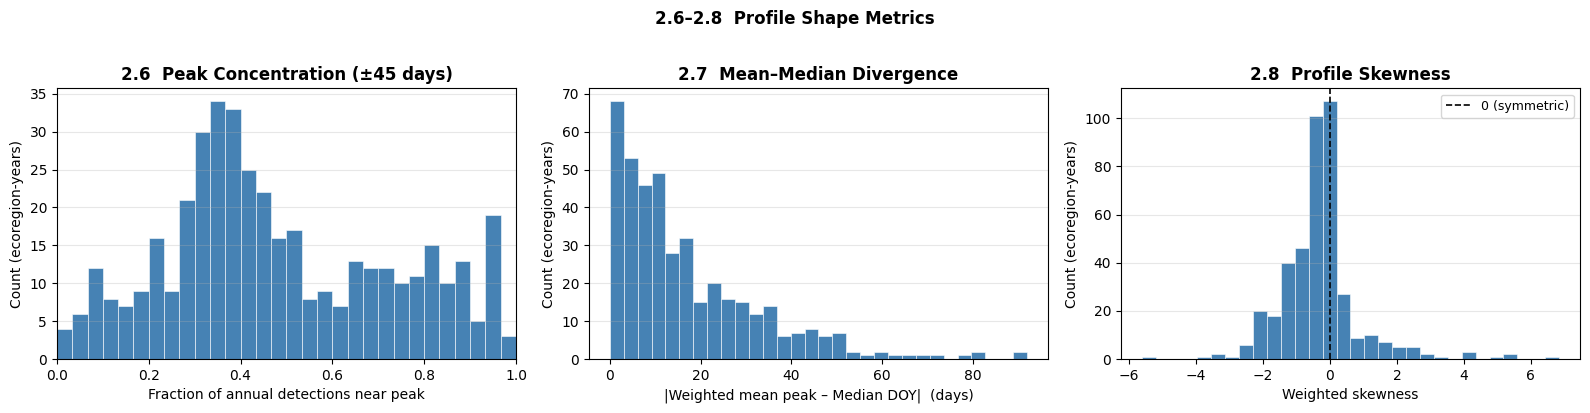

In [8]:
# PLOTS 2.6–2.8 — PROFILE SHAPE METRICS ----------------------------------------------------------
# 2.6  Peak concentration — fraction of detections within ±45 days of peak.
#      Low values flag diffuse or potentially bimodal activity.
# 2.7  Mean–median divergence in days.
#      Large values flag asymmetric seasons where threshold metrics may be unreliable.
# 2.8  Weighted skewness of the detection profile.
#      Positive = long right tail (slow end). Negative = long left tail (slow start).

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('2.6–2.8  Profile Shape Metrics',
             fontsize=12, fontweight='bold', y=1.02)

# 2.6 — Peak concentration
ax = axes[0]
ax.hist(master_df['peak_concentration'].dropna(), bins=30,
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('2.6  Peak Concentration (±45 days)', fontweight='bold')
ax.set_xlabel('Fraction of annual detections near peak')
ax.set_ylabel('Count (ecoregion-years)')
ax.set_xlim(0, 1)
ax.grid(axis='y', alpha=0.3)

# 2.7 — Mean–median divergence
ax = axes[1]
ax.hist(master_df['mean_median_div'].dropna(), bins=30,
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('2.7  Mean–Median Divergence', fontweight='bold')
ax.set_xlabel('|Weighted mean peak – Median DOY|  (days)')
ax.set_ylabel('Count (ecoregion-years)')
ax.grid(axis='y', alpha=0.3)

# 2.8 — Skewness
ax = axes[2]
ax.hist(master_df['skewness'].dropna(), bins=30,
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--', label='0 (symmetric)')
ax.set_title('2.8  Profile Skewness', fontweight='bold')
ax.set_xlabel('Weighted skewness')
ax.set_ylabel('Count (ecoregion-years)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

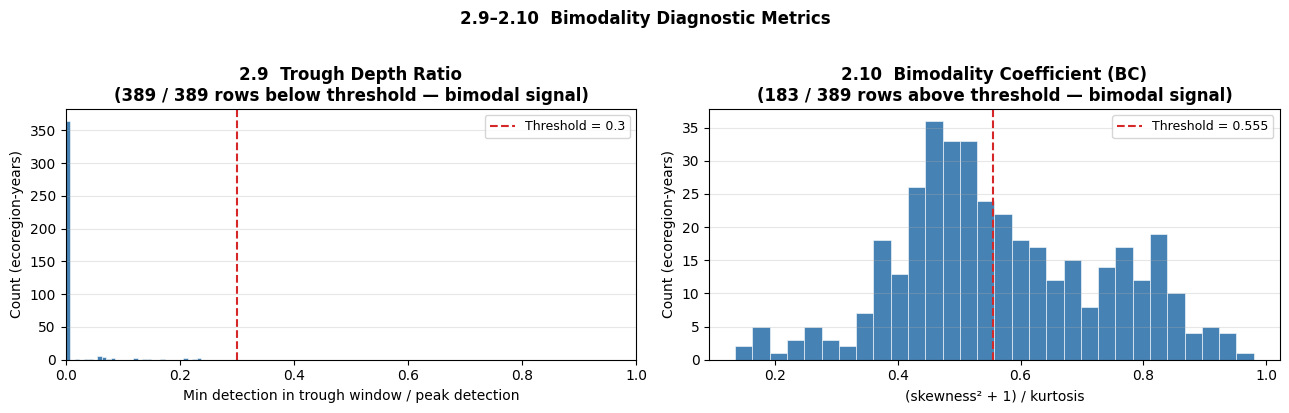

In [9]:
# PLOTS 2.9–2.10 — BIMODALITY DIAGNOSTIC METRICS ------------------------------------------------
# Both metrics are only computed when season_length > 90 days.
# NaN values (short seasons) are excluded automatically via dropna().
# Threshold lines show the current flagging thresholds for context.
#
# 2.9   Trough depth ratio — min detection in 60-day mid-season window / peak detection.
#        Near 0 = deep trough between two seasons. Near 1 = activity stays high throughout.
# 2.10  Bimodality coefficient (BC) — (skewness² + 1) / kurtosis.
#        Above 0.555 = more bimodal than a uniform distribution.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('2.9–2.10  Bimodality Diagnostic Metrics',
             fontsize=12, fontweight='bold', y=1.02)

# 2.9 — Trough depth ratio
ax = axes[0]
trough_vals = master_df['trough_depth_ratio'].dropna()
ax.hist(trough_vals, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(TROUGH_THRESHOLD, color=C_PEAK, linewidth=1.5, linestyle='--',
           label=f'Threshold = {TROUGH_THRESHOLD}')
n_below = int((trough_vals < TROUGH_THRESHOLD).sum())
ax.set_title(
    f'2.9  Trough Depth Ratio\n'
    f'({n_below} / {len(trough_vals)} rows below threshold — bimodal signal)',
    fontweight='bold'
)
ax.set_xlabel('Min detection in trough window / peak detection')
ax.set_ylabel('Count (ecoregion-years)')
ax.set_xlim(0, 1)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 2.10 — Bimodality coefficient
ax = axes[1]
bc_vals = master_df['bc'].dropna()
ax.hist(bc_vals, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(BC_THRESHOLD, color=C_PEAK, linewidth=1.5, linestyle='--',
           label=f'Threshold = {BC_THRESHOLD}')
n_above = int((bc_vals > BC_THRESHOLD).sum())
ax.set_title(
    f'2.10  Bimodality Coefficient (BC)\n'
    f'({n_above} / {len(bc_vals)} rows above threshold — bimodal signal)',
    fontweight='bold'
)
ax.set_xlabel('(skewness² + 1) / kurtosis')
ax.set_ylabel('Count (ecoregion-years)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

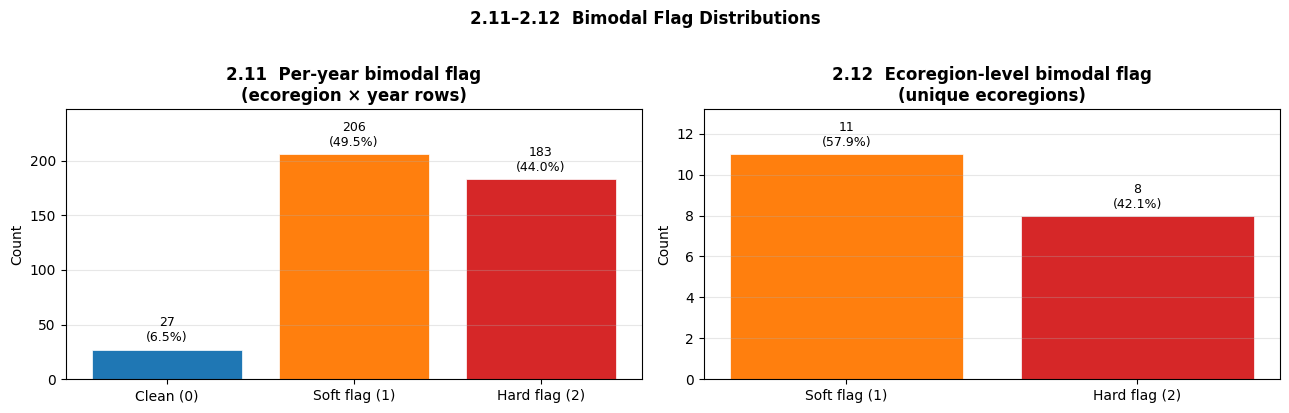

In [10]:
# PLOTS 2.11–2.12 — BIMODAL FLAG DISTRIBUTIONS ---------------------------------------------------
# 2.11  Per-year bimodal flag (bimodal_flag_year): one observation per ecoregion-year.
# 2.12  Ecoregion-level bimodal flag (bimodal_flag_eco): one observation per ecoregion.
# If 80%+ of ecoregion-years are soft-flagged in 2.11, TROUGH_THRESHOLD may be too loose.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('2.11–2.12  Bimodal Flag Distributions',
             fontsize=12, fontweight='bold', y=1.02)

def flag_bar_chart(ax, series, title):
    '''Draw a bar chart of flag value counts with count and % labels.'''
    counts = series.value_counts().sort_index()
    colors = [C_FLAGS.get(k, '#aaaaaa') for k in counts.index]
    labels = [L_FLAGS.get(k, str(k))    for k in counts.index]
    bars   = ax.bar(labels, counts.values, color=colors,
                    edgecolor='white', linewidth=0.5)
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.012,
            f'{val}\n({val / total * 100:.1f}%)',
            ha='center', va='bottom', fontsize=9
        )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.20)
    ax.grid(axis='y', alpha=0.3)

flag_bar_chart(
    axes[0], master_df['bimodal_flag_year'],
    '2.11  Per-year bimodal flag\n(ecoregion × year rows)'
)
flag_bar_chart(
    axes[1], quality_df['bimodal_flag_eco'],
    '2.12  Ecoregion-level bimodal flag\n(unique ecoregions)'
)

plt.tight_layout()
plt.show()

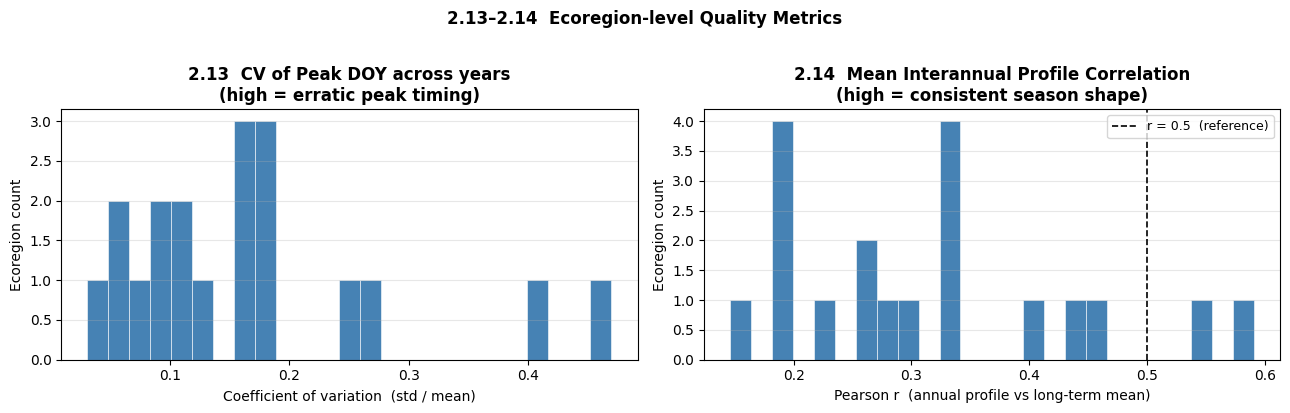

In [11]:
# PLOTS 2.13–2.14 — ECOREGION-LEVEL QUALITY METRICS ---------------------------------------------
# These are computed across years per ecoregion and live in _eco_quality.csv.
# 2.13  CV of peak DOY — std / mean across valid years. High = erratic timing.
# 2.14  Mean interannual profile correlation. High = consistent season shape year to year.
#        Values below 0.5 suggest the season shape is inconsistent and metrics are unreliable.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('2.13–2.14  Ecoregion-level Quality Metrics',
             fontsize=12, fontweight='bold', y=1.02)

# 2.13 — CV of peak DOY
ax = axes[0]
cv_vals = quality_df['cv_peak_doy'].dropna()
ax.hist(cv_vals, bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('2.13  CV of Peak DOY across years\n(high = erratic peak timing)',
             fontweight='bold')
ax.set_xlabel('Coefficient of variation  (std / mean)')
ax.set_ylabel('Ecoregion count')
ax.grid(axis='y', alpha=0.3)

# 2.14 — Mean interannual profile correlation
ax = axes[1]
corr_vals = quality_df['mean_profile_corr'].dropna()
ax.hist(corr_vals, bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0.5, color='black', linewidth=1.2, linestyle='--',
           label='r = 0.5  (reference)')
ax.set_title('2.14  Mean Interannual Profile Correlation\n'
             '(high = consistent season shape)',
             fontweight='bold')
ax.set_xlabel("Pearson r  (annual profile vs long-term mean)")
ax.set_ylabel('Ecoregion count')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

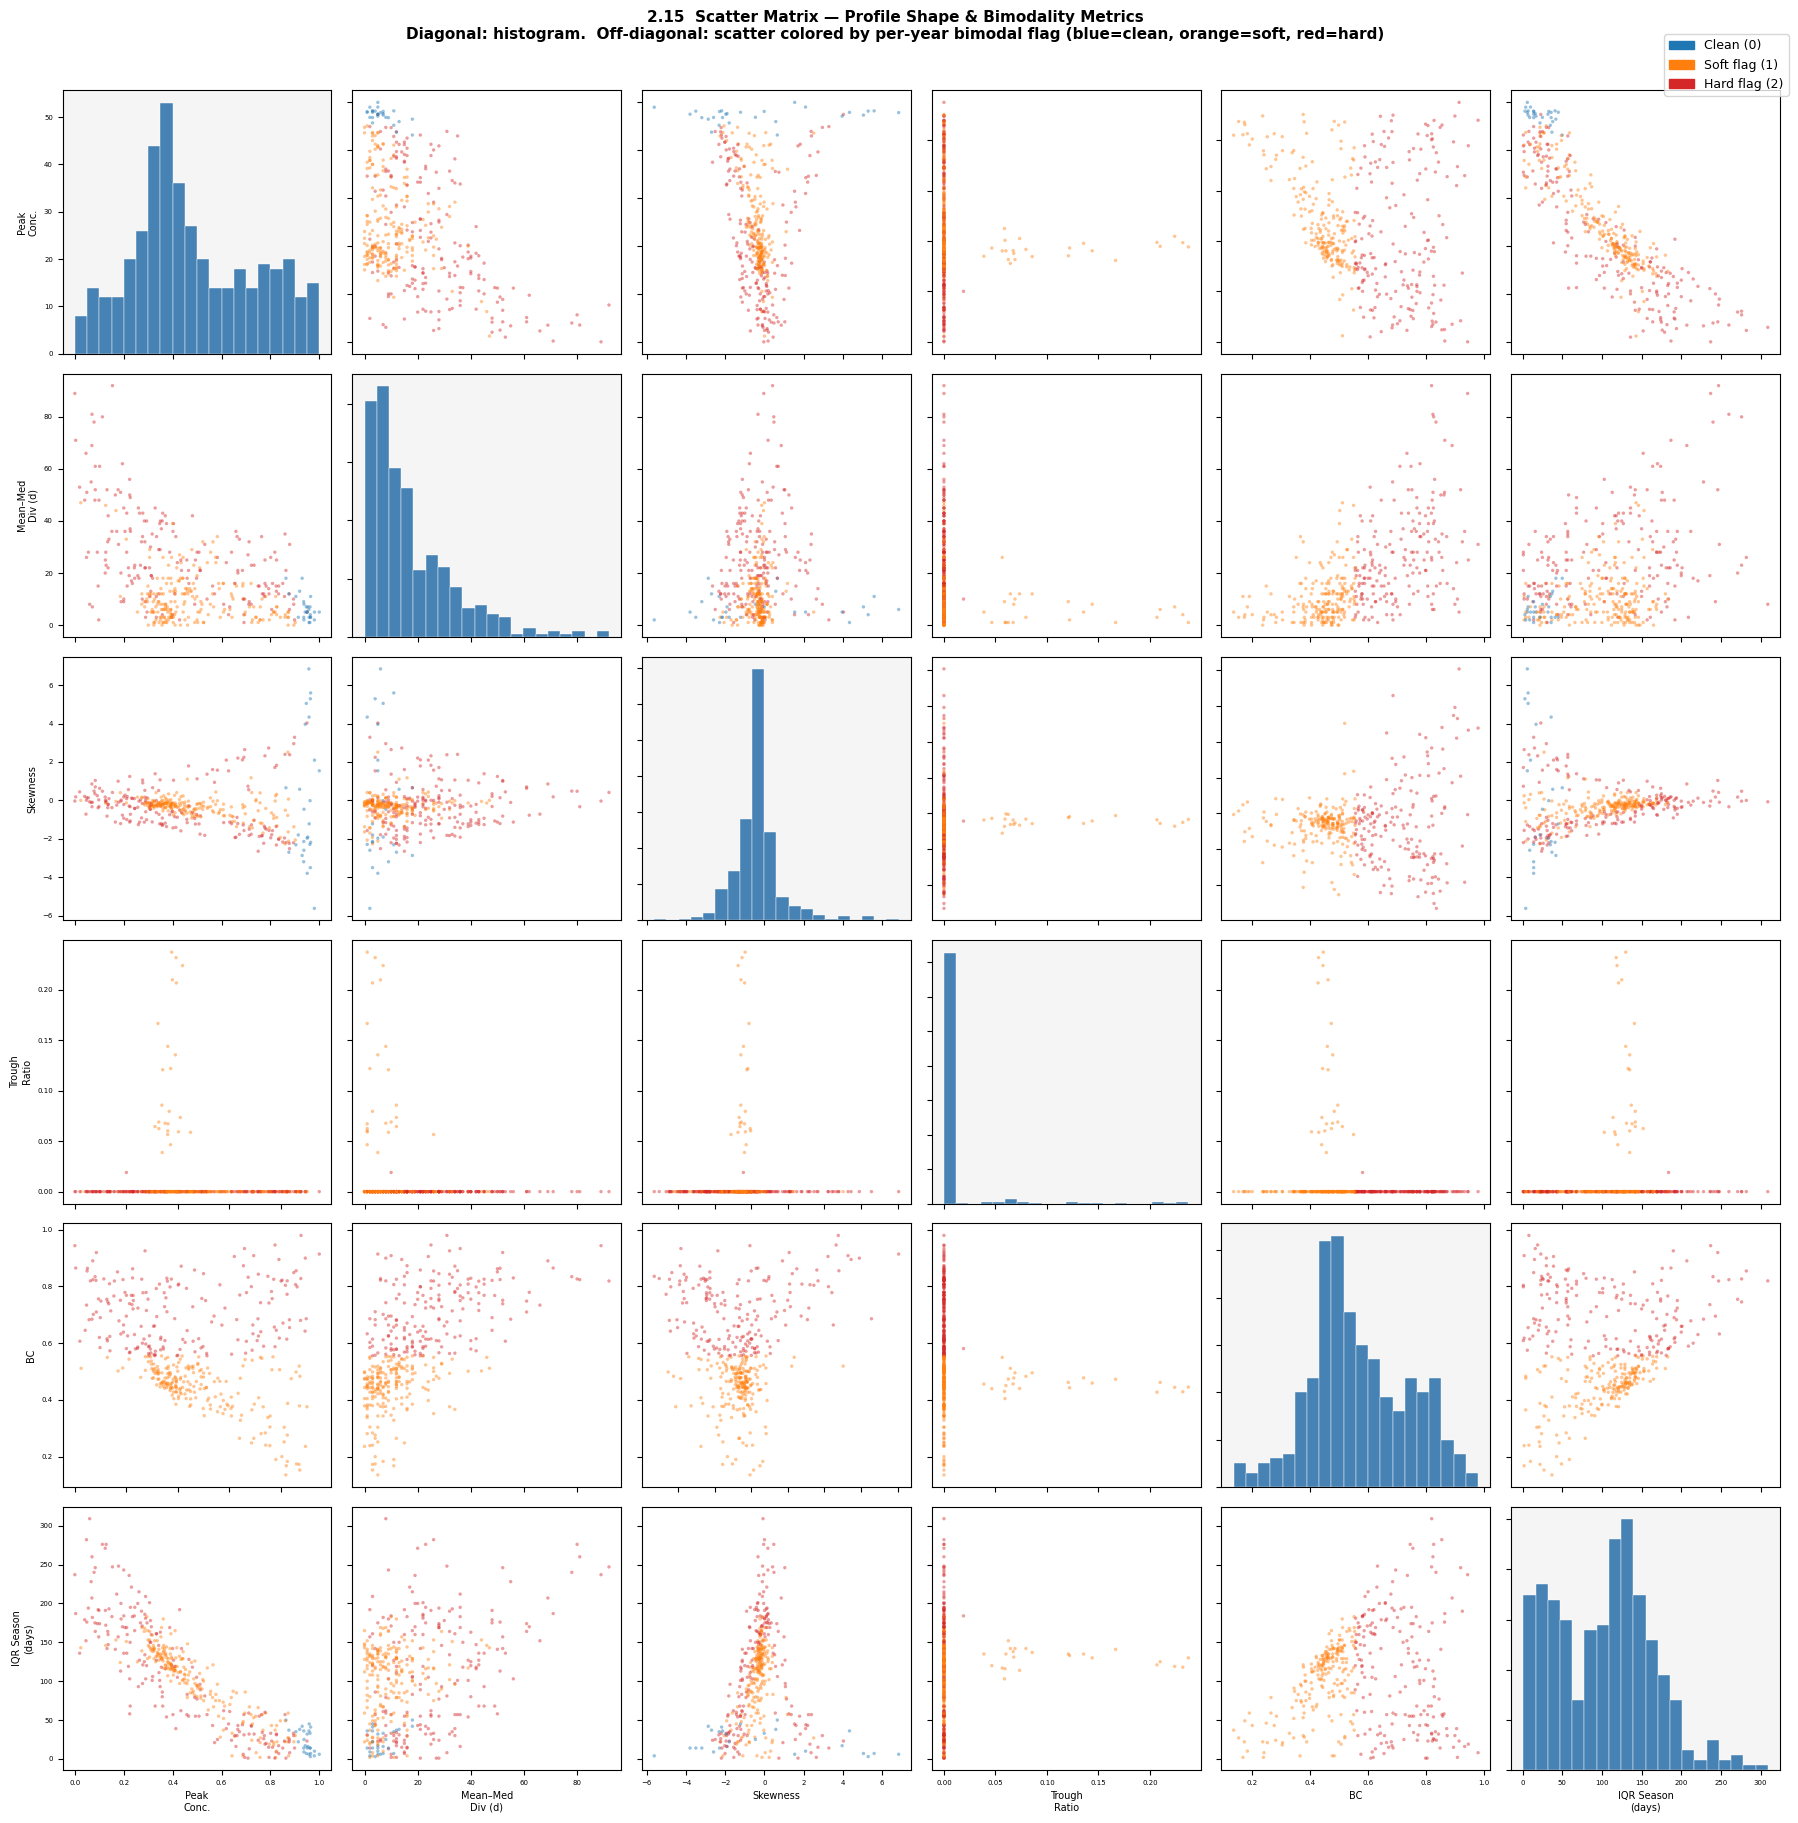

In [12]:
# PLOT 2.15 — SCATTER MATRIX OF QUALITY AND BIMODALITY METRICS -----------------------------------
# 6 × 6 grid of panels.
# Diagonal  : histogram of that variable.
# Off-diagonal : scatter plot of the two variables, colored by bimodal_flag_year.
# Variables chosen to capture profile shape reliability and bimodality risk together.

SCAT_VARS = [
    ('peak_concentration', 'Peak\nConc.'),
    ('mean_median_div',    'Mean–Med\nDiv (d)'),
    ('skewness',           'Skewness'),
    ('trough_depth_ratio', 'Trough\nRatio'),
    ('bc',                 'BC'),
    ('iqr_season_length',  'IQR Season\n(days)'),
]
N = len(SCAT_VARS)

fig, axes = plt.subplots(N, N, figsize=(18, 18))
fig.suptitle(
    '2.15  Scatter Matrix — Profile Shape & Bimodality Metrics\n'
    'Diagonal: histogram.  Off-diagonal: scatter colored by per-year bimodal flag '
    '(blue=clean, orange=soft, red=hard)',
    fontsize=11, fontweight='bold', y=1.01
)

flag_colors = master_df['bimodal_flag_year'].map(C_FLAGS).fillna('#aaaaaa').values

for i, (var_y, label_y) in enumerate(SCAT_VARS):
    for j, (var_x, label_x) in enumerate(SCAT_VARS):
        ax = axes[i, j]
        x  = master_df[var_x].values.astype(float)
        y  = master_df[var_y].values.astype(float)

        if i == j:
            # Diagonal — histogram
            valid = ~np.isnan(x)
            ax.hist(x[valid], bins=20,
                    color='steelblue', edgecolor='white', linewidth=0.3)
            ax.set_facecolor('#f5f5f5')
        else:
            # Off-diagonal — scatter
            valid = ~np.isnan(x) & ~np.isnan(y)
            ax.scatter(x[valid], y[valid],
                       c=flag_colors[valid], s=6, alpha=0.45, linewidths=0)

        # Axis labels on outer edges only
        if i == N - 1:
            ax.set_xlabel(label_x, fontsize=7)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(label_y, fontsize=7)
        else:
            ax.set_yticklabels([])

        ax.tick_params(labelsize=5)

# Legend
legend_handles = [
    mpatches.Patch(color=C_FLAGS[k], label=L_FLAGS[k]) for k in sorted(C_FLAGS)
]
fig.legend(handles=legend_handles, loc='upper right',
           fontsize=9, bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

## Section 3 — Per-ecoregion Profile Plots


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

eco_ids = sorted(master_df['eco_id'].unique())

for eco_id in eco_ids:
    eco_rows   = master_df[master_df['eco_id'] == eco_id]
    daily_rows = daily_df[daily_df['eco_id'] == eco_id].copy()

    eco_name   = eco_rows['eco_name'].iloc[0]
    biome_name = eco_rows['biome_name'].iloc[0]

    q_row      = quality_df[quality_df['eco_id'] == eco_id]
    flag_eco   = int(q_row['bimodal_flag_eco'].iloc[0]) if len(q_row) else 0
    corr_eco   = float(q_row['mean_profile_corr'].iloc[0]) if len(q_row) and pd.notna(q_row['mean_profile_corr'].iloc[0]) else np.nan
    cv_eco     = float(q_row['cv_peak_doy'].iloc[0]) if len(q_row) and pd.notna(q_row['cv_peak_doy'].iloc[0]) else np.nan

    # ---- FULL GRID (year × doy) ----
    years = sorted(daily_rows['year'].unique())
    full_grid = pd.MultiIndex.from_product([years, range(1, 366)], names=['year', 'doy']).to_frame(index=False)

    daily_full = (
        full_grid
        .merge(daily_rows[['year', 'doy', 'n_detections']], on=['year', 'doy'], how='left')
        .fillna({'n_detections': 0})
    )

    # ---- OPTIONAL: normalize per year (recommended for shape) ----
    daily_full['year_total'] = daily_full.groupby('year')['n_detections'].transform('sum')
    daily_full['prop'] = np.where(
        daily_full['year_total'] > 0,
        daily_full['n_detections'] / daily_full['year_total'],
        0
    )

    # ---- AGGREGATE PROFILE ----
    prof = (
        daily_full
        .groupby('doy')['prop']   # change to 'n_detections' if you want raw counts
        .agg(
            mean='mean',
            q25=lambda x: np.quantile(x, 0.25),
            q75=lambda x: np.quantile(x, 0.75),
            q10=lambda x: np.quantile(x, 0.10),
            q90=lambda x: np.quantile(x, 0.90)
        )
        .reset_index()
    )

    # ---- SMOOTH (important) ----
    prof['mean_smooth'] = prof['mean'].rolling(15, center=True, min_periods=1).mean()

    # ---- SEASON METRICS (aggregated) ----
    m_valid = eco_rows.dropna(subset=['onset_doy', 'peak_doy', 'end_doy'])

    onset_mean  = m_valid['onset_doy'].mean() if len(m_valid) else np.nan
    peak_mean   = m_valid['peak_doy'].mean() if len(m_valid) else np.nan
    median_mean = m_valid['median_doy'].mean() if 'median_doy' in m_valid.columns and len(m_valid) else np.nan
    end_mean    = m_valid['end_doy'].mean() if len(m_valid) else np.nan
    season_len  = (m_valid['end_doy'] - m_valid['onset_doy']).mean() if len(m_valid) else np.nan

    # ---- PLOT ----
    fig, ax = plt.subplots(figsize=(9, 4.5))

    # variability ribbons
    ax.fill_between(prof['doy'], prof['q10'], prof['q90'], alpha=0.15, label='10–90%')
    ax.fill_between(prof['doy'], prof['q25'], prof['q75'], alpha=0.30, label='25–75%')

    # mean profile
    ax.plot(prof['doy'], prof['mean_smooth'], linewidth=2.2, label='Mean profile')

    # markers
    if pd.notna(onset_mean):
        ax.axvline(onset_mean, linewidth=1.2, label='Onset')
    if pd.notna(peak_mean):
        ax.axvline(peak_mean, linewidth=1.2, label='Peak')
        ax.axvspan(max(1, peak_mean - 45), min(365, peak_mean + 45),
                   alpha=0.10, label='Peak ±45d')
    if pd.notna(median_mean):
        ax.axvline(median_mean, linestyle='--', linewidth=1.0, label='Median')
    if pd.notna(end_mean):
        ax.axvline(end_mean, linewidth=1.2, label='End')

    # axes
    ax.set_xlim(1, 365)
    ax.set_xticks(MONTH_STARTS)
    ax.set_xticklabels(MONTH_NAMES)
    ax.set_ylabel('Proportion of annual detections')
    ax.set_xlabel('Day of year')

    # title
    title = (
        f'{eco_name} (ID: {eco_id})\n'
        f'Biome: {biome_name} | '
        f'Flag: {L_FLAGS.get(flag_eco, flag_eco)} | '
        f'Corr: {corr_eco:.3f} | CV peak: {cv_eco:.3f} | '
        f'Season length: {season_len:.1f} d'
    )
    ax.set_title(title, fontsize=10)

    ax.legend(fontsize=8, ncol=3, frameon=False)
    plt.tight_layout()

    safe_name = eco_name.replace(' ', '_').replace('/', '_')
    save_path = os.path.join(profile_dir, f'{eco_id}_{safe_name}_climatology.png')
    plt.savefig(save_path, dpi=FIG_DPI, bbox_inches='tight')
    plt.close()

## Section 4 — Bimodality Flag Inspection


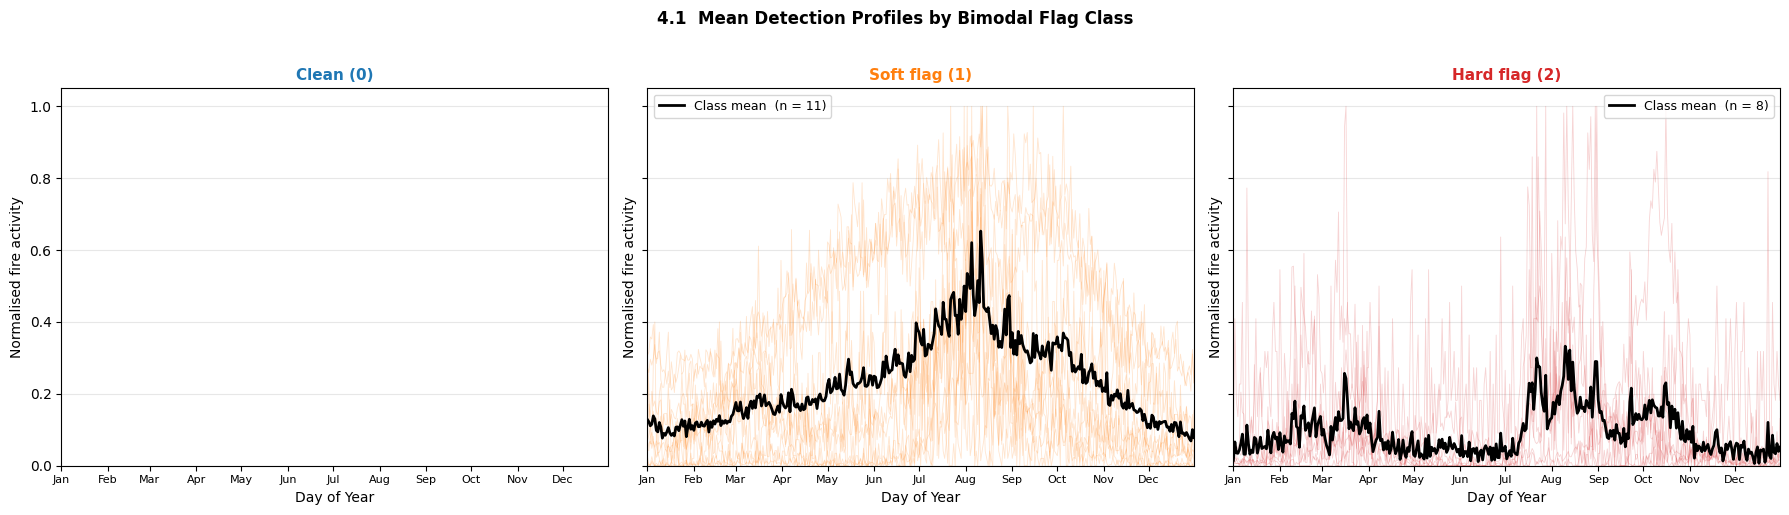

In [14]:
# PLOT 4.1 — MEAN DETECTION PROFILES BY FLAG CLASS -----------------------------------------------
# Three panels, one per ecoregion bimodal flag class (0=clean, 1=soft, 2=hard).
# Each ecoregion in the class: compute mean annual detection profile across all valid years,
# normalise to [0, 1], draw as thin semi-transparent line.
# Thick black line = class-wide mean across all ecoregion profiles.
# If hard-flagged ecoregions look structurally different, flagging is working.

DOY_RANGE = list(range(1, 366))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('4.1  Mean Detection Profiles by Bimodal Flag Class',
             fontsize=12, fontweight='bold', y=1.02)

for flag_val, ax in zip([0, 1, 2], axes):

    eco_ids_class = quality_df[quality_df['bimodal_flag_eco'] == flag_val]['eco_id'].values
    all_profiles  = []

    for eco_id in eco_ids_class:
        eco_daily = daily_df[daily_df['eco_id'] == eco_id]
        if eco_daily.empty:
            continue

        # Pivot to years × doy; reindex to full 1–365 range
        pivot = eco_daily.pivot_table(
            index='year', columns='doy',
            values='n_detections', fill_value=0
        ).reindex(columns=DOY_RANGE, fill_value=0)

        mean_prof = pivot.mean(axis=0).values.astype(float)
        max_val   = mean_prof.max()
        if max_val == 0:
            continue

        norm_prof = mean_prof / max_val
        ax.plot(DOY_RANGE, norm_prof, color=C_FLAGS[flag_val],
                alpha=0.20, linewidth=0.6)
        all_profiles.append(norm_prof)

    if all_profiles:
        class_mean = np.mean(all_profiles, axis=0)
        ax.plot(DOY_RANGE, class_mean, color='black', linewidth=2.0,
                label=f'Class mean  (n = {len(all_profiles)})')
        ax.legend(fontsize=9)

    ax.set_xticks(MONTH_STARTS)
    ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.set_xlim(1, 365)
    ax.set_ylim(0, 1.05)
    ax.set_title(L_FLAGS[flag_val], fontsize=11,
                 fontweight='bold', color=C_FLAGS[flag_val])
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Normalised fire activity')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

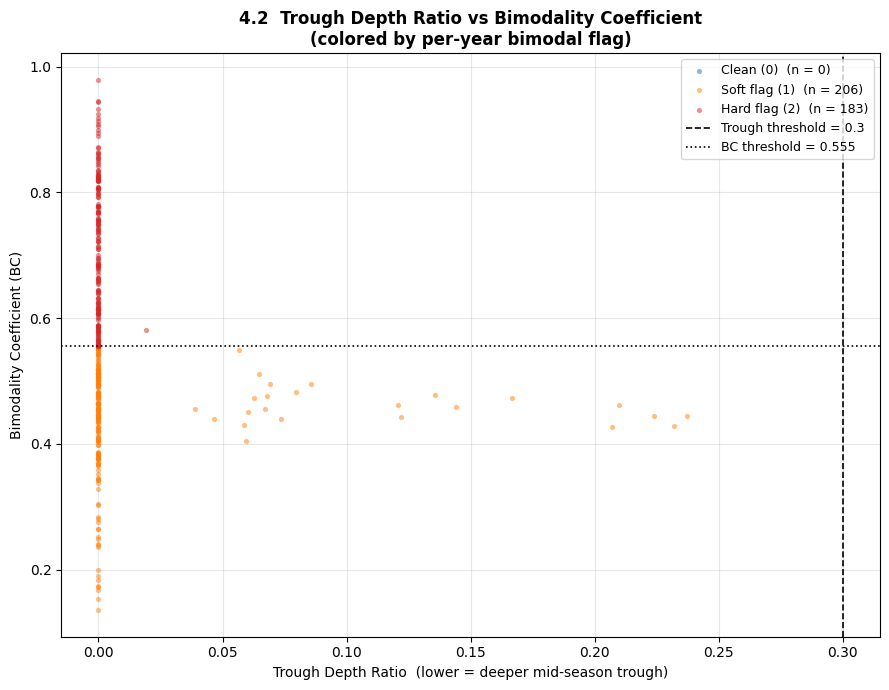

In [15]:
# PLOT 4.2 — TROUGH DEPTH RATIO vs BIMODALITY COEFFICIENT ----------------------------------------
# Scatter of the two bimodality metrics. Each point is one ecoregion-year.
# Colored by bimodal_flag_year. Threshold crosshairs divide the space into four quadrants.
# Hard-flagged points should cluster in the top-left quadrant:
#   low trough ratio (deep trough) AND high BC (bimodal statistical signature).
# Disagreements between the two metrics are informative edge cases.

fig, ax = plt.subplots(figsize=(9, 7))

valid = master_df['trough_depth_ratio'].notna() & master_df['bc'].notna()
df_v  = master_df[valid].copy()

for flag_val in [0, 1, 2]:
    sub = df_v[df_v['bimodal_flag_year'] == flag_val]
    ax.scatter(sub['trough_depth_ratio'], sub['bc'],
               c=C_FLAGS[flag_val], s=14, alpha=0.5, linewidths=0,
               label=f'{L_FLAGS[flag_val]}  (n = {len(sub)})', zorder=2)

ax.axvline(TROUGH_THRESHOLD, color='black', linewidth=1.2, linestyle='--',
           label=f'Trough threshold = {TROUGH_THRESHOLD}', zorder=3)
ax.axhline(BC_THRESHOLD,     color='black', linewidth=1.2, linestyle=':',
           label=f'BC threshold = {BC_THRESHOLD}', zorder=3)

ax.set_xlabel('Trough Depth Ratio  (lower = deeper mid-season trough)', fontsize=10)
ax.set_ylabel('Bimodality Coefficient (BC)', fontsize=10)
ax.set_title('4.2  Trough Depth Ratio vs Bimodality Coefficient\n'
             '(colored by per-year bimodal flag)',
             fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

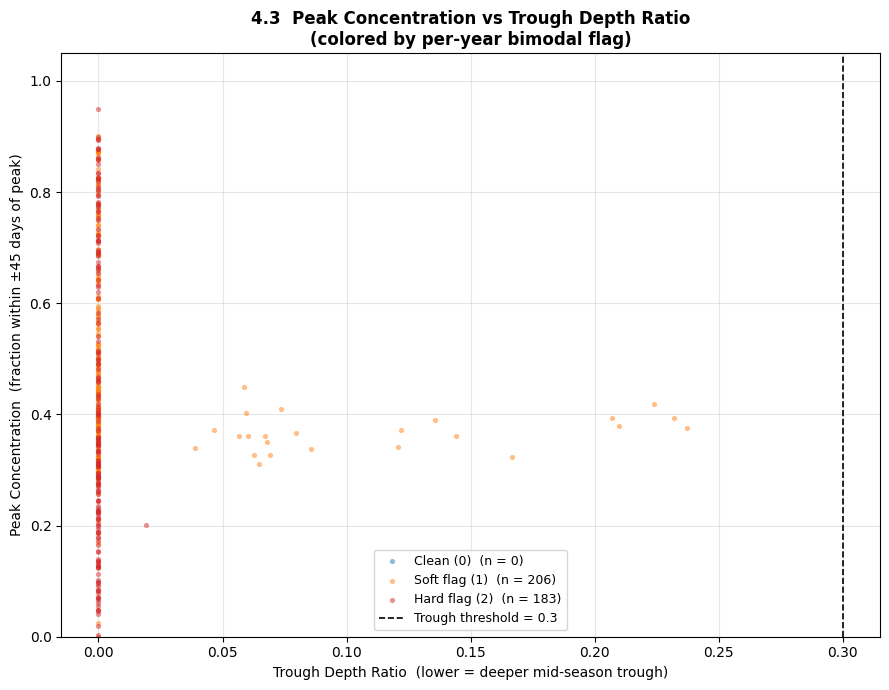

In [16]:
# PLOT 4.3 — PEAK CONCENTRATION vs TROUGH DEPTH RATIO --------------------------------------------
# Peak concentration and trough depth ratio measure bimodality from different angles.
# They should broadly agree: low concentration AND low trough ratio = bimodal.
# Points that strongly disagree between the two are interesting edge cases:
#   High concentration + low trough ratio — tight peak but structural gap in middle.
#   Low concentration + high trough ratio — diffuse activity but no mid-season trough.

fig, ax = plt.subplots(figsize=(9, 7))

valid = master_df['trough_depth_ratio'].notna() & master_df['peak_concentration'].notna()
df_v  = master_df[valid].copy()

for flag_val in [0, 1, 2]:
    sub = df_v[df_v['bimodal_flag_year'] == flag_val]
    ax.scatter(sub['trough_depth_ratio'], sub['peak_concentration'],
               c=C_FLAGS[flag_val], s=14, alpha=0.5, linewidths=0,
               label=f'{L_FLAGS[flag_val]}  (n = {len(sub)})', zorder=2)

ax.axvline(TROUGH_THRESHOLD, color='black', linewidth=1.2, linestyle='--',
           label=f'Trough threshold = {TROUGH_THRESHOLD}', zorder=3)

ax.set_xlabel('Trough Depth Ratio  (lower = deeper mid-season trough)', fontsize=10)
ax.set_ylabel('Peak Concentration  (fraction within ±45 days of peak)', fontsize=10)
ax.set_title('4.3  Peak Concentration vs Trough Depth Ratio\n'
             '(colored by per-year bimodal flag)',
             fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

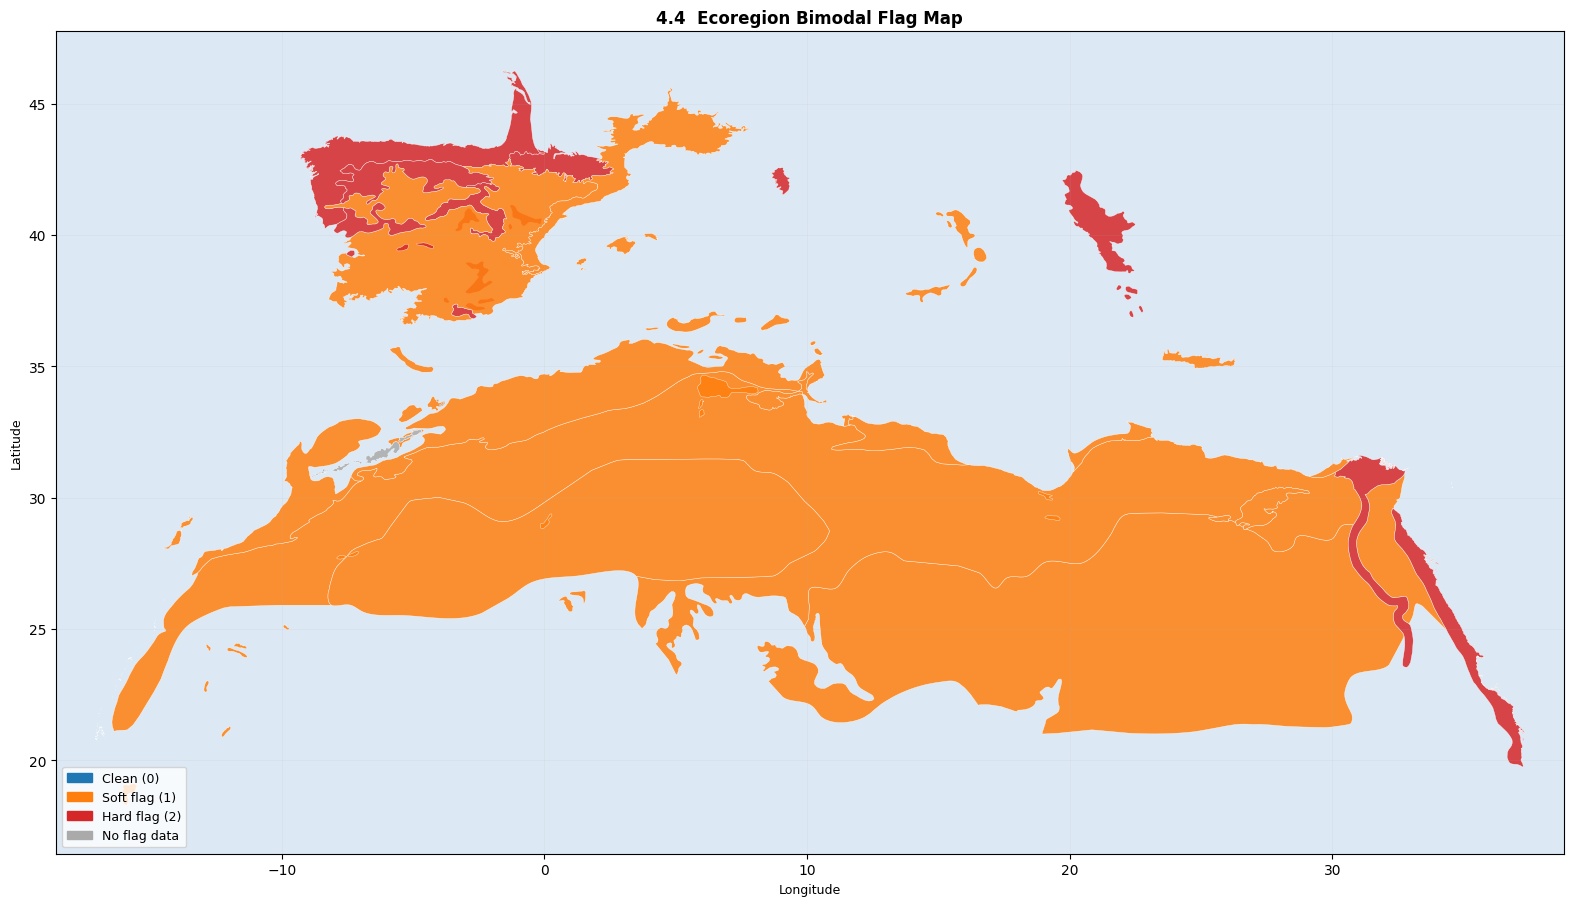

In [17]:
# PLOT 4.4 — MAP OF ECOREGIONS COLORED BY BIMODAL FLAG CLASS ------------------------------------
# Polygon patches drawn from eco_geometries.json. No GEE or geopandas required.
# Handles both Polygon and MultiPolygon geometry types.
# Color: blue=clean, orange=soft flag, red=hard flag, grey=no flag data.

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_facecolor('#dce9f5')
fig.patch.set_facecolor('white')

flag_lookup = quality_df.set_index('eco_id')['bimodal_flag_eco'].to_dict()

def extract_rings(geometry):
    '''Return a list of coordinate rings from a GeoJSON Polygon or MultiPolygon.'''
    geo_type = geometry.get('type', '')
    coords   = geometry.get('coordinates', [])
    if geo_type == 'Polygon':
        return [coords[0]] if coords else []
    elif geo_type == 'MultiPolygon':
        return [poly[0] for poly in coords if poly]
    return []

# Collect all patches and accumulate coordinate bounds for axis limits
all_patches = []
all_lons    = []
all_lats    = []

for eco_id, geometry in geo_lookup.items():
    flag_val = flag_lookup.get(eco_id, -1)
    color    = C_FLAGS.get(flag_val, '#aaaaaa')

    for ring in extract_rings(geometry):
        if len(ring) < 3:
            continue
        xy = [(pt[0], pt[1]) for pt in ring]
        all_lons += [pt[0] for pt in xy]
        all_lats += [pt[1] for pt in xy]
        patch = Polygon(xy, closed=True,
                        facecolor=color, edgecolor='white',
                        linewidth=0.3, alpha=0.85)
        all_patches.append(patch)
        ax.add_patch(patch)

# Set extent from coordinate data with a small padding
if all_lons and all_lats:
    pad = 1.5
    ax.set_xlim(min(all_lons) - pad, max(all_lons) + pad)
    ax.set_ylim(min(all_lats) - pad, max(all_lats) + pad)

ax.set_aspect('equal')
ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)
ax.set_title('4.4  Ecoregion Bimodal Flag Map',
             fontsize=12, fontweight='bold')

legend_handles = [
    mpatches.Patch(color=C_FLAGS[k], label=L_FLAGS[k]) for k in sorted(C_FLAGS)
] + [mpatches.Patch(color='#aaaaaa', label='No flag data')]
ax.legend(handles=legend_handles, loc='lower left', fontsize=9)
ax.grid(alpha=0.2, linewidth=0.4)
plt.tight_layout()
plt.show()

## Section 5 — Summary Report


In [18]:
# SUMMARY REPORT ----------------------------------------------------------------------------------
# One row per ecoregion. Merges pipeline quality metrics with sanity check outcomes.
#
# recommended_status values:
#   CLEAN     — no flags, no sanity failures
#   SOFT_FLAG — at least one flag, but no hard flag and no sanity failure
#   HARD_FLAG — hard bimodal flag (bimodal_flag_eco == 2)
#   CHECK     — failed at least one sanity check (inspect manually regardless of flag)
#
# Requires Section 1 to have been run for any_sanity_fail to be accurate.
# If Section 1 was skipped, fail_index defaults to empty set.

try:
    _ = fail_index
except NameError:
    fail_index = set()
    print('Warning: Section 1 (sanity checks) was not run.')
    print('         any_sanity_fail will be False for all ecoregions.')
    print()

fail_eco_ids = {eco_id for (eco_id, _yr) in fail_index}

summary_rows = []

for _, q_row in quality_df.iterrows():
    eco_id = q_row['eco_id']

    ref        = eco_ref[eco_ref['eco_id'] == eco_id]
    eco_name   = ref['eco_name'].iloc[0]   if len(ref) else ''
    biome_name = ref['biome_name'].iloc[0] if len(ref) else ''

    rows_eco        = master_df[master_df['eco_id'] == eco_id]
    n_years_valid   = int(rows_eco['n_years_valid'].iloc[0])    if len(rows_eco) else 0
    pct_years_valid = float(rows_eco['pct_years_valid'].iloc[0]) if len(rows_eco) else 0.0

    flag_eco        = int(q_row['bimodal_flag_eco'])
    frac_soft       = float(q_row['frac_soft_flagged'])
    frac_hard       = float(q_row['frac_hard_flagged'])
    mean_corr       = float(q_row['mean_profile_corr']) \
                      if pd.notna(q_row['mean_profile_corr']) else None
    cv_peak         = float(q_row['cv_peak_doy']) \
                      if pd.notna(q_row['cv_peak_doy'])       else None
    any_sanity_fail = eco_id in fail_eco_ids

    if any_sanity_fail:
        status = 'CHECK'
    elif flag_eco == 2:
        status = 'HARD_FLAG'
    elif flag_eco == 1:
        status = 'SOFT_FLAG'
    else:
        status = 'CLEAN'

    summary_rows.append({
        'eco_id'            : eco_id,
        'eco_name'          : eco_name,
        'biome_name'        : biome_name,
        'n_years_valid'     : n_years_valid,
        'pct_years_valid'   : pct_years_valid,
        'mean_profile_corr' : mean_corr,
        'cv_peak_doy'       : cv_peak,
        'bimodal_flag_eco'  : flag_eco,
        'frac_soft_flagged' : frac_soft,
        'frac_hard_flagged' : frac_hard,
        'any_sanity_fail'   : int(any_sanity_fail),
        'recommended_status': status,
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = os.path.join(output_dir, '_validation_summary.csv')
summary_df.to_csv(summary_path, index=False)

print('=' * 68)
print('VALIDATION SUMMARY')
print('=' * 68)
status_counts = summary_df['recommended_status'].value_counts()
for status, count in status_counts.sort_index().items():
    pct = count / len(summary_df) * 100
    print(f'  {status:<12} : {count:>4}  ({pct:.1f}%)')
print('-' * 68)
print(f'  Total        : {len(summary_df):>4}  ecoregions')
print('=' * 68)
print()
print(f'Saved: {os.path.abspath(summary_path)}')
print()
print(summary_df[[
    'eco_id', 'eco_name', 'n_years_valid',
    'bimodal_flag_eco', 'recommended_status'
]].to_string(index=False))

VALIDATION SUMMARY
  HARD_FLAG    :    8  (42.1%)
  SOFT_FLAG    :   11  (57.9%)
--------------------------------------------------------------------
  Total        :   19  ecoregions

Saved: C:\Users\ibekar\Documents\GitProjects\TGPF\outputs\med_basin_v2\_validation_summary.csv

 eco_id                                                          eco_name  n_years_valid  bimodal_flag_eco recommended_status
  648.0                                          Cantabrian mixed forests             23                 2          HARD_FLAG
  676.0                                Pyrenees conifer and mixed forests             23                 2          HARD_FLAG
  701.0                           Mediterranean conifer and mixed forests             23                 1          SOFT_FLAG
  744.0                                        Nile Delta flooded savanna             23                 2          HARD_FLAG
  745.0                                               Saharan halophytics             16 